In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('AmesHousing.csv')

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Step 1

In [3]:
print(df.shape)
print(df.columns)
print(df.index)

(2930, 82)
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr B

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

The variables are shown in the output above, and they have the datatypes string, int, or float.

In [5]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

The output above shows the distribution of the "SalePrice" column.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

The output above shows that there are a few columns with missing values.

# Step 2 - Create training and test data

In [7]:
from sklearn.model_selection import train_test_split

# SalePrice is the target. Order and PID are just row/parcel IDs, not features.
X = df.drop(columns=['SalePrice', 'Order', 'PID'])
y = df['SalePrice']

# 80% training, 20% test. random_state makes the split the same every run.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)

Training set: (2344, 79)
Test set:     (586, 79)


# Step 3 - Prepare the data

Everything here is learned from the training data only, then applied the same way to the test data.

## Unusual observations

Four training houses are over 4,000 sq ft. Two of them sold very cheaply (unfinished "Partial" sales). There are too few houses this large to learn from, so we remove them from the training data. The test data is not changed.

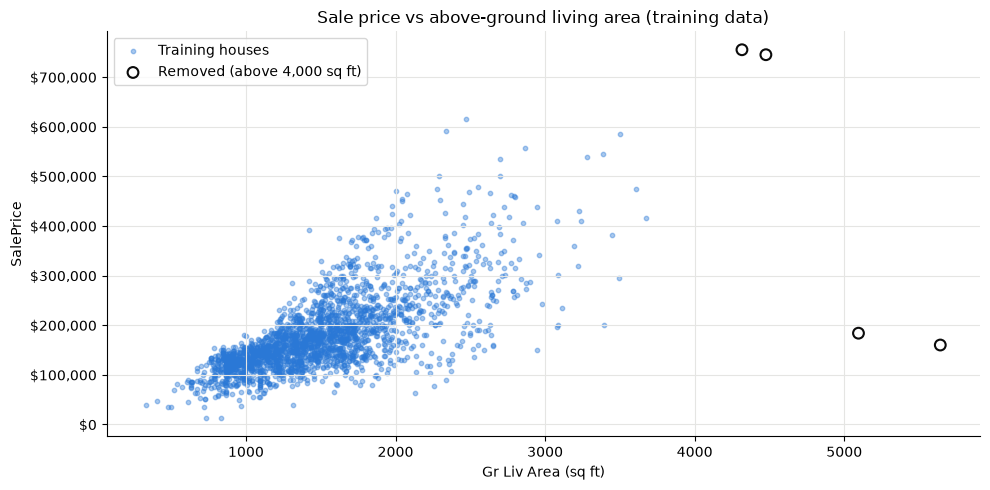

      Gr Liv Area Sale Condition  SalePrice
1498         5642        Partial     160000
1760         4476        Abnorml     745000
1767         4316         Normal     755000
2180         5095        Partial     183850
Training set after removal: (2340, 79)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

large = X_train['Gr Liv Area'] > 4000

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_train.loc[~large, 'Gr Liv Area'], y_train[~large],
           s=10, alpha=0.4, color='#2a78d6', label='Training houses')
ax.scatter(X_train.loc[large, 'Gr Liv Area'], y_train[large],
           s=60, facecolors='none', edgecolors='#0b0b0b', linewidths=1.5,
           label='Removed (above 4,000 sq ft)')
ax.set_title('Sale price vs above-ground living area (training data)')
ax.set_xlabel('Gr Liv Area (sq ft)')
ax.set_ylabel('SalePrice')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.grid(color='#e5e5e3', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Gr Liv Area': X_train.loc[large, 'Gr Liv Area'],
                    'Sale Condition': X_train.loc[large, 'Sale Condition'],
                    'SalePrice': y_train[large]}))

X_train = X_train[~large]
y_train = y_train[~large]
print('Training set after removal:', X_train.shape)

In [9]:
# Missing values per column in the training data
missing = X_train.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Pool QC           2330
Misc Feature      2247
Alley             2178
Fence             1871
Mas Vnr Type      1425
Fireplace Qu      1144
Lot Frontage       393
Garage Cond        122
Garage Yr Blt      122
Garage Finish      122
Garage Qual        122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Total Bsmt SF        1
Bsmt Full Bath       1
BsmtFin SF 2         1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

## Missing values

The guide says a missing value means either:

- **Not present** (e.g. no pool, no garage) → we use the category `"None"`.
- **Not recorded** → we fill it later: numbers get the training median, categories get `"Unknown"`.

Ordered categories (e.g. Po < Fa < TA < Gd < Ex) are turned into numbers that keep the order. `MS SubClass` is a category code, so it is turned into text.

In [10]:
import numpy as np

# Missing always means the feature is not present
absent_cols = ['Alley', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']
# Missing means no basement/garage, unless related columns show that one exists
bsmt_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
garage_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

# Ordered categories from the guide -> numbers, with 0 for "None"
quality = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_scales = {
    'Exter Qual': quality, 'Exter Cond': quality, 'Bsmt Qual': quality,
    'Bsmt Cond': quality, 'Heating QC': quality, 'Kitchen Qual': quality,
    'Fireplace Qu': quality, 'Garage Qual': quality, 'Garage Cond': quality,
    'Pool QC': quality,
    'Lot Shape': {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'Utilities': {'NoSeWa': 0, 'NoSewr': 1, 'AllPub': 2},
    'Land Slope': {'Sev': 0, 'Mod': 1, 'Gtl': 2},
    'Bsmt Exposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFin Type 1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFin Type 2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional': {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7},
    'Garage Finish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Paved Drive': {'N': 0, 'P': 1, 'Y': 2},
}


def clean(X):
    X = X.copy()

    # 1. Feature not present -> "None"
    X[absent_cols] = X[absent_cols].fillna('None')

    has_bsmt = X['Total Bsmt SF'] > 0
    for col in bsmt_cols:
        X.loc[X[col].isna() & ~has_bsmt, col] = 'None'

    has_garage = X['Garage Type'].notna() | (X['Garage Area'] > 0)
    for col in garage_cols:
        X.loc[X[col].isna() & ~has_garage, col] = 'None'

    X.loc[X['Mas Vnr Type'].isna() & (X['Mas Vnr Area'] == 0), 'Mas Vnr Type'] = 'None'

    # 2. Anything still missing is "not recorded" and is filled later from the training data

    # Ordered categories -> numbers (a missing value stays missing)
    for col, scale in ordinal_scales.items():
        X[col] = X[col].map(scale)

    # MS SubClass numbers are category codes, not measurements
    X['MS SubClass'] = X['MS SubClass'].astype(str)
    return X


X_train_clean = clean(X_train)
X_test_clean = clean(X_test)

# What is left is information that was not recorded
missing = X_train_clean.isna().sum()
missing[missing > 0]

Lot Frontage      393
Mas Vnr Type       26
Mas Vnr Area       19
Bsmt Exposure       2
BsmtFin SF 1        1
BsmtFin Type 2      1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Bsmt Full Bath      1
Bsmt Half Bath      1
Garage Yr Blt     122
Garage Finish       2
Garage Cars         1
Garage Area         1
Garage Qual         2
Garage Cond         2
dtype: int64

## Removing variables

- `Garage Yr Blt`: missing when there is no garage, very similar to `Year Built`, and has a typo (2207).
- Columns where one value covers 99% or more of the rows, since they tell us almost nothing.

In [11]:
print('Garage Yr Blt vs Year Built correlation:',
      round(X_train['Garage Yr Blt'].corr(X_train['Year Built']), 2))
print('Latest Garage Yr Blt:', X_train['Garage Yr Blt'].max())

# Share of the most common value in each column (training data only)
top_share = X_train_clean.apply(lambda col: col.value_counts(normalize=True).iloc[0])
near_constant = top_share[top_share >= 0.99].index.tolist()

drop_cols = ['Garage Yr Blt'] + near_constant
print('Dropping:', drop_cols)

X_train_clean = X_train_clean.drop(columns=drop_cols)
X_test_clean = X_test_clean.drop(columns=drop_cols)

Garage Yr Blt vs Year Built correlation: 0.82
Latest Garage Yr Blt: 2207.0
Dropping: ['Garage Yr Blt', 'Street', 'Utilities', 'Condition 2', 'Pool Area', 'Pool QC']


# Step 4 - Select and engineer features

`X_train_clean` at this point still has one column per original variable (missing values handled, quality scales turned into numbers, near-useless columns removed) but is not yet one-hot encoded or scaled. This is the easiest point to look for evidence of which features actually relate to `SalePrice`, and to build new features from them - anything we add here will automatically be median-imputed and scaled by the `ColumnTransformer` further down, since that step reads whatever columns `X_train_clean` has at the time it runs.

In [ ]:
# Correlation of every remaining numeric column with SalePrice (training data only).
# This includes the quality columns from Step 3, since those are now numbers too.
numeric_cols = X_train_clean.select_dtypes(include='number').columns
correlations = X_train_clean[numeric_cols].corrwith(y_train).sort_values(key=abs, ascending=False)
correlations.head(20)

## What the correlations show

`Overall Qual` (0.81), `Gr Liv Area` (0.72), `Exter Qual` (0.71) and `Kitchen Qual` (0.69) are the strongest single predictors — a mix of *how good the house is* (the quality ratings, which is why turning them into ordered numbers in Step 3 mattered) and *how big it is*. Size-related columns (`Total Bsmt SF`, `1st Flr SF`, `Garage Cars`/`Garage Area`) and age (`Year Built`, `Year Remod/Add`) also correlate strongly. This matches common sense about houses, which is a good sanity check that preprocessing did not break anything.

One thing stands out: several of the strongest features measure **overlapping information about size** (`Gr Liv Area`, `1st Flr SF`, `Total Bsmt SF` all describe square footage of different parts of the house, just added up differently). This is the evidence behind the feature we engineer next.

## Engineering new features

Based on the correlations above and general knowledge about houses, we build four new features:

- **`Total SF`** = `Total Bsmt SF` + `1st Flr SF` + `2nd Flr SF` — total square footage of the house, basement included. `Gr Liv Area` already covers the above-ground part; this adds the basement, which `Gr Liv Area` leaves out.
- **`House Age`** = `Yr Sold` - `Year Built` — how old the house was *at the time it was sold*. This is more directly meaningful than the raw construction year.
- **`Years Since Remodel`** = `Yr Sold` - `Year Remod/Add` — how long ago the house was last updated.
- **`Total Bathrooms`** = `Full Bath` + 0.5 x `Half Bath` + `Bsmt Full Bath` + 0.5 x `Bsmt Half Bath` — combines all four separate bathroom-count columns into one number of "bathroom equivalents", which is closer to how a buyer would actually think about a house.

All four are computed from columns that already exist on that same row, so there is nothing to "learn" from the training data here — the same formula is safe to apply to `X_test_clean` too, unlike a median or a category list.

In [ ]:
def engineer_features(X):
    X = X.copy()
    X['Total SF'] = X['Total Bsmt SF'] + X['1st Flr SF'] + X['2nd Flr SF']
    X['House Age'] = X['Yr Sold'] - X['Year Built']
    # A handful of rows have Year Remod/Add one year after Yr Sold (likely a new
    # build recorded before the paperwork caught up) - clip at 0 since "minus
    # one year since the last remodel" is not meaningful.
    X['Years Since Remodel'] = (X['Yr Sold'] - X['Year Remod/Add']).clip(lower=0)
    X['Total Bathrooms'] = (X['Full Bath'] + 0.5 * X['Half Bath']
                             + X['Bsmt Full Bath'] + 0.5 * X['Bsmt Half Bath'])
    return X


# A few components (e.g. Total Bsmt SF) still have the odd not-yet-imputed
# missing value at this point - any new feature built from them becomes NaN
# on that same row, which the median imputer downstream will fill in later,
# exactly like every other numeric column.
X_train_clean = engineer_features(X_train_clean)
X_test_clean = engineer_features(X_test_clean)

new_features = ['Total SF', 'House Age', 'Years Since Remodel', 'Total Bathrooms']
X_train_clean[new_features].corrwith(y_train)

## Reading the result

`Total SF` correlates with `SalePrice` at about **0.83** - stronger than *any* single original column, including `Overall Qual` (0.81) and `Gr Liv Area` (0.72) alone. `Total Bathrooms` (~0.64) is also a stronger predictor than any of the four individual bathroom columns it combines. `House Age` and `Years Since Remodel` both correlate negatively (older / longer-unremodeled houses sell for less), as expected.

**We keep the original columns (`Gr Liv Area`, `1st Flr SF`, the bathroom counts, etc.) alongside the new ones**, rather than deleting them. The new features overlap with their components, but:
- `DecisionTreeRegressor` and `RandomForestRegressor` are not hurt by redundant/correlated columns - they just pick whichever feature gives the best split at each point.
- `LinearRegression` can become harder to interpret with highly correlated inputs (multicollinearity spreads the same effect across several coefficients), but it does not make the *predictions* wrong, and interpreting individual coefficients is not something this assignment asks us to do.

So the size/age/quality picture from the correlation table, plus these four engineered features, is our evidence for **Q2** and **Q5**: which columns matter, and why we added `Total SF`, `House Age`, `Years Since Remodel` and `Total Bathrooms` on top of them.

## Filling, scaling and encoding

- Numbers: fill missing with the median, then scale.
- Categories: fill missing with `"Unknown"`, then one-hot encode.

This is fitted on the training data only.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns
    cat_cols = X.select_dtypes(exclude='number').columns

    numeric_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols),
    ])


preprocessor = build_preprocessor(X_train_clean)

# Learn medians, scaling and categories from the training data only...
X_train_prep = preprocessor.fit_transform(X_train_clean)
# ...and apply exactly the same transformation to the test data
X_test_prep = preprocessor.transform(X_test_clean)

print('Numerical columns:  ', X_train_clean.select_dtypes(include='number').shape[1])
print('Categorical columns:', X_train_clean.select_dtypes(exclude='number').shape[1])
print('Training set after preprocessing:', X_train_prep.shape)
print('Test set after preprocessing:    ', X_test_prep.shape)

Numerical columns:   50
Categorical columns: 23
Training set after preprocessing: (2340, 237)
Test set after preprocessing:     (586, 237)


## Transforming the target

`SalePrice` is skewed to the right, so we use log(SalePrice). Predictions must be converted back with `np.expm1` before calculating RMSE.

In [13]:
print('Skewness of SalePrice:     ', round(y_train.skew(), 2))
print('Skewness of log(SalePrice):', round(np.log1p(y_train).skew(), 2))

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Skewness of SalePrice:      1.53
Skewness of log(SalePrice): -0.13
